In [1]:
!pip install tensorflow
!pip install matplotlib
!pip install numpy

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [5]:
train_dir = "chest_xray/train"
val_dir = "chest_xray/val"
test_dir = "chest_xray/test"

In [6]:
train_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

val_generator = train_datagen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [7]:
model = tf.keras.models.Sequential([
    
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128,activation='relu'),
    
    tf.keras.layers.Dense(1,activation='sigmoid')
])

C:\Users\SMBU-HJX\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.9176 - loss: 0.2099 - val_accuracy: 0.8750 - val_loss: 0.2460
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.9634 - loss: 0.0997 - val_accuracy: 0.8750 - val_loss: 0.3741
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.9728 - loss: 0.0711 - val_accuracy: 0.8750 - val_loss: 0.1761
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.9749 - loss: 0.0628 - val_accuracy: 0.8125 - val_loss: 0.3024
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.9787 - loss: 0.0565 - val_accuracy: 0.9375 - val_loss: 0.1284


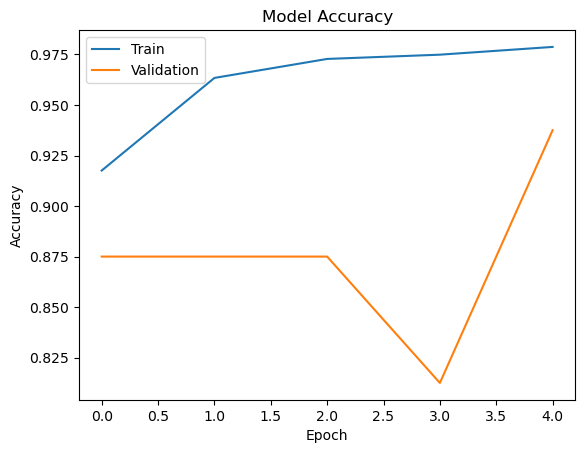

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

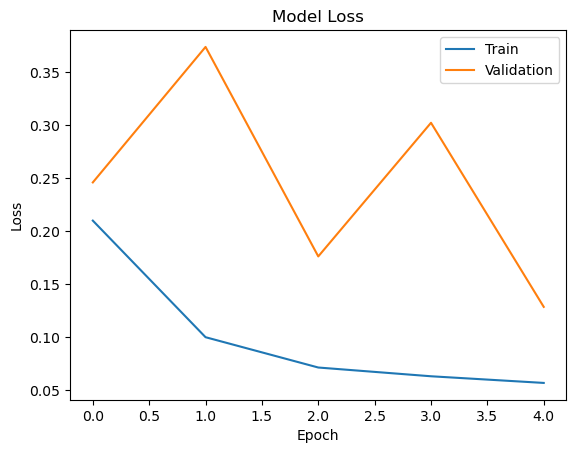

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [12]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "chest_xray/test",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_loss, test_acc = model.evaluate(test_generator)

print("Test accuracy:", test_acc)

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.7436 - loss: 1.4978 
Test accuracy: 0.7435897588729858
